In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\cleaned_stats.csv")

In [4]:
df.columns

Index(['Unnamed: 0', 'id', 'date_insert', 'sensor_id', 'wtempV_°C',
       'conductivity_of_solution_ mS_cm', 'oxidation_reduction_potential_ mV',
       'total_suspended_solids_mg_L', 'turbidity_NTU',
       'dissolved_oxygen_concentration _ppm',
       'dissolved_oxygen_concentration_mg_L', 'oxygen_saturation_%',
       'salinity_ppt', 'dissolved_solids _ppm', 'location'],
      dtype='object')

In [5]:
# Define feature groups (excluding wtemp)
features_to_scale = [
    'conductivity_of_solution_ mS_cm', 
    'oxidation_reduction_potential_ mV', 
    'oxygen_saturation_%'
]
turbidity_col = 'turbidity_NTU'
sensor_id_col = 'sensor_id'  # Replace with your actual column name if different

# Set how heavily to prioritize turbidity over other features
TURBIDITY_WEIGHT = 2.5

# List to collect processed dataframes
processed_sensor_dfs = []

In [6]:
unique_sensors = df[sensor_id_col].unique()

for sensor in unique_sensors:
    # Isolate data for a single sensor
    sensor_df = df[df[sensor_id_col] == sensor].copy()
    
    # Skip sensors with insufficient data to form 3 clusters
    if len(sensor_df) < 3:
        continue
        
    scaler = StandardScaler()
    
    # Scale the 3 base features
    scaled_matrix = scaler.fit_transform(sensor_df[features_to_scale])
    df_scaled = pd.DataFrame(scaled_matrix, columns=features_to_scale, index=sensor_df.index)
    
    # Scale and weight turbidity separately
    scaled_turbidity = scaler.fit_transform(sensor_df[[turbidity_col]])
    df_scaled[turbidity_col] = scaled_turbidity * TURBIDITY_WEIGHT
    
    # Run K-Means directly on all 4 scaled columns
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    
    sensor_df['temp_cluster'] = cluster_labels
    
    # Calculate average turbidity per cluster and sort (lowest to highest)
    turbidity_means = sensor_df.groupby('temp_cluster')[turbidity_col].mean().sort_values()
    
    # Map clusters explicitly by their sorted turbidity index position
    label_mapping = {
        turbidity_means.index[0]: 'Ok',      # Lowest average turbidity
        turbidity_means.index[1]: 'Medium',  # Middle average turbidity
        turbidity_means.index[2]: 'Danger'   # Highest average turbidity
    }
    
    # Map the text labels and clean up
    sensor_df['Water_Quality_Label'] = sensor_df['temp_cluster'].map(label_mapping)
    sensor_df.drop(columns=['temp_cluster'], inplace=True)
    
    processed_sensor_dfs.append(sensor_df)

# Combine everything back into your master training dataset
final_training_df = pd.concat(processed_sensor_dfs, axis=0)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [7]:
# Show how many rows fall into each class across the city
print("--- Overall Label Distribution ---")
print(final_training_df['Water_Quality_Label'].value_counts())

# Show a quick profile to confirm 'Danger' has the highest turbidity
print("\n--- Feature Averages by Quality Label ---")
profile_cols = [turbidity_col] + features_to_scale
print(final_training_df.groupby('Water_Quality_Label')[profile_cols].mean())

--- Overall Label Distribution ---
Water_Quality_Label
Medium    6676
Ok        4291
Danger    2855
Name: count, dtype: int64

--- Feature Averages by Quality Label ---
                     turbidity_NTU  conductivity_of_solution_ mS_cm  \
Water_Quality_Label                                                   
Danger                  450.061443                     51897.482161   
Medium                  217.197758                     50822.008818   
Ok                       83.715237                     54559.710883   

                     oxidation_reduction_potential_ mV  oxygen_saturation_%  
Water_Quality_Label                                                          
Danger                                      133.656855            72.962305  
Medium                                      168.268683            70.856708  
Ok                                          106.877215            73.558049  


C:\Users\User\AppData\Local\Temp\ipykernel_18264\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18264\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18264\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_18264\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

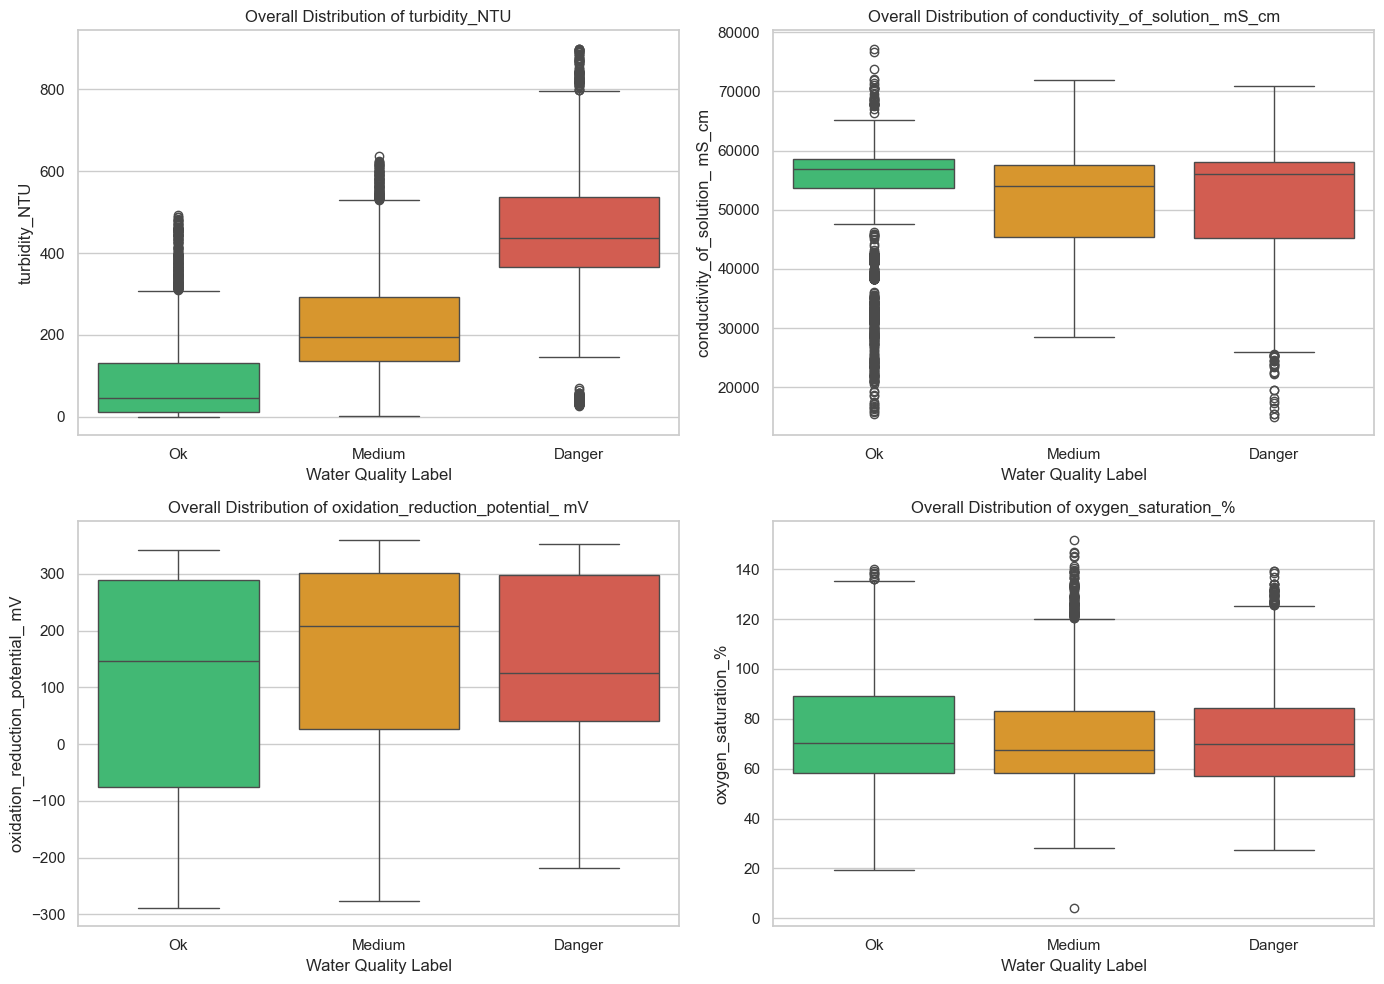

In [8]:
# Set up the plotting style and layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Explicitly order the labels on the X-axis for logical scanning
label_order = ['Ok', 'Medium', 'Danger']
palette = {'Ok': '#2ecc71', 'Medium': '#f39c12', 'Danger': '#e74c3c'} # Green, Orange, Red

# List of the 4 original measurement columns to plot
metrics = [
    'turbidity_NTU', 
    'conductivity_of_solution_ mS_cm', 
    'oxidation_reduction_potential_ mV', 
    'oxygen_saturation_%'
]

# Generate a boxplot for each metric
for i, metric in enumerate(metrics):
    sns.boxplot(
        data=final_training_df, 
        x='Water_Quality_Label', 
        y=metric, 
        order=label_order, 
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(f'Overall Distribution of {metric}')
    axes[i].set_xlabel('Water Quality Label')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

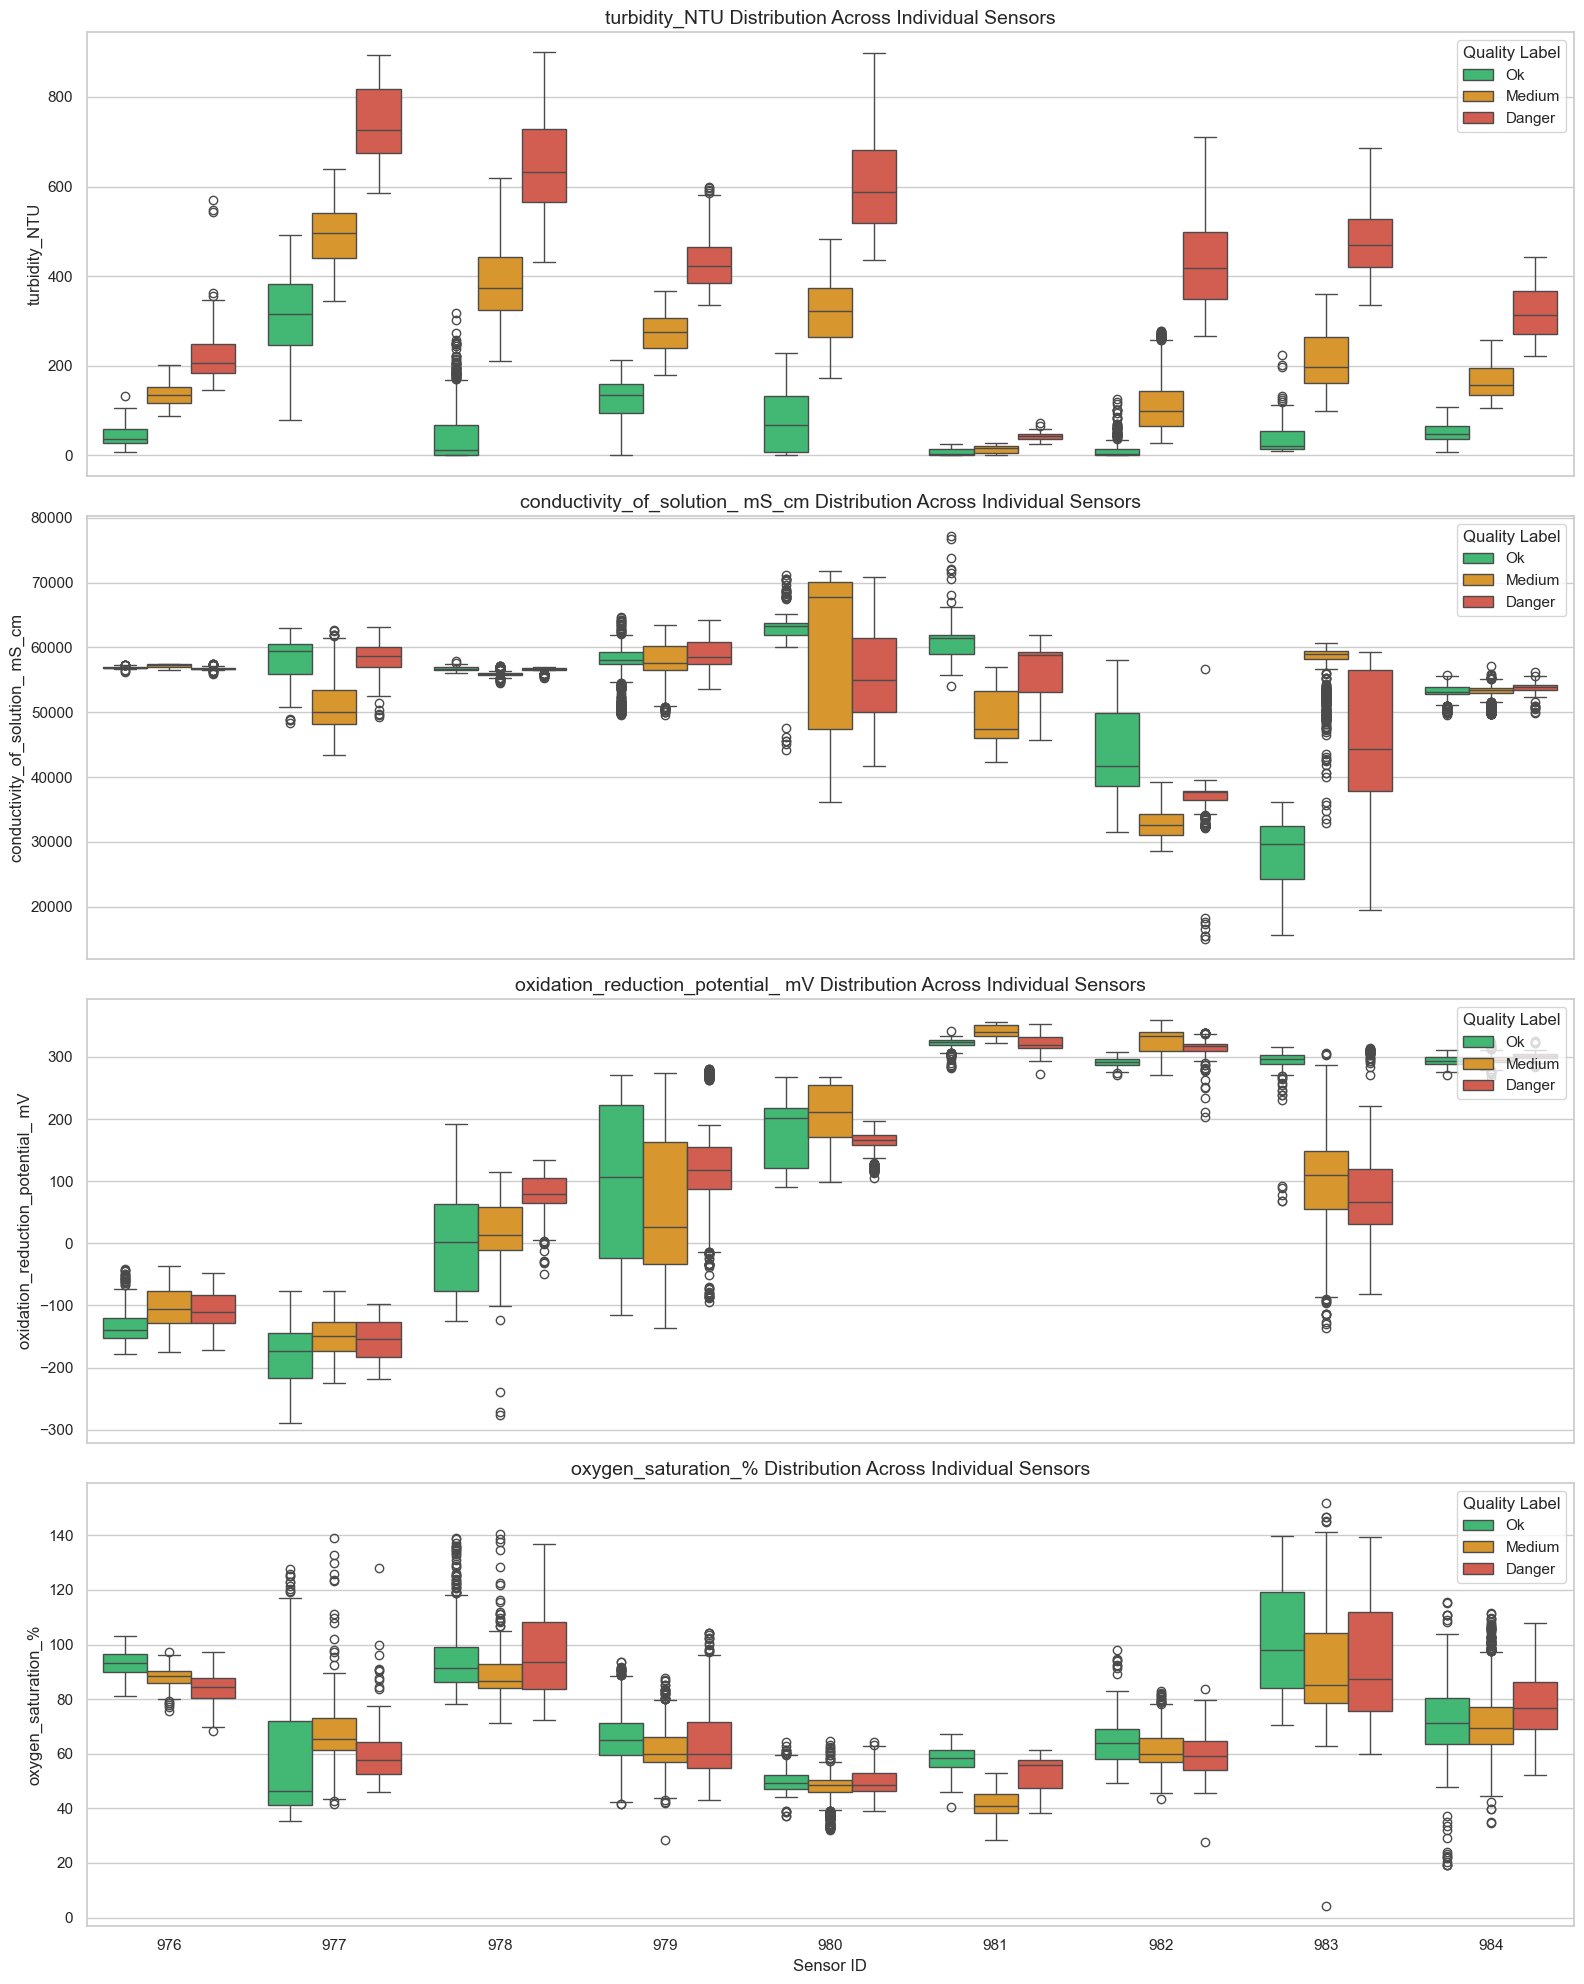

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)

# Sort Sensor IDs so the X-axis stays consistently ordered
sensor_order = sorted(final_training_df['sensor_id'].unique())

for i, metric in enumerate(metrics):
    sns.boxplot(
        data=final_training_df,
        x='sensor_id',
        y=metric,
        hue='Water_Quality_Label',
        hue_order=label_order,
        palette=palette,
        order=sensor_order,
        ax=axes[i]
    )
    axes[i].set_title(f'{metric} Distribution Across Individual Sensors', fontsize=14)
    axes[i].set_xlabel('Sensor ID' if i == 3 else '') # Only show label on the bottom plot
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].legend(title='Quality Label', loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
final_training_df.to_csv(r"C:\Users\User\Desktop\water\data\labeled_water_stats.csv")

In [10]:
final_training_df.groupby(
["sensor_id","Water_Quality_Label"]
)[[
"turbidity_NTU",
"conductivity_of_solution_ mS_cm",
"oxidation_reduction_potential_ mV",
"oxygen_saturation_%"
]].describe()

turbidity_NTU                                  \
                                      count        mean         std     min   
sensor_id Water_Quality_Label                                                 
976       Danger                      192.0  222.187708   62.297345  145.96   
          Medium                      383.0  136.872454   26.037871   88.86   
          Ok                          482.0   44.585498   21.860796    8.06   
977       Danger                      171.0  736.955848   81.769693  585.45   
          Medium                      258.0  491.691628   71.408009  344.35   
          Ok                          392.0  310.638750   97.458431   79.77   
978       Danger                      177.0  652.239040  111.879254  432.12   
          Medium                      665.0  383.561820   85.500748  210.63   
          Ok                          682.0   45.380821   64.000136    0.00   
979       Danger                      651.0  428.040077   51.506769  335.00   
          Medium                      928.0  272.350075   43.723558  178.71   
          Ok                          944.0  117.669047   61.417724    0.00   
980       Danger                      253.0  604.241858  108.541962  436.55   
          Medium                      528.0  320.408598   68.796048  172.13   
          Ok                          396.0   76.953939   68.960827    0.00   
981       Danger                       86.0   42.928372    9.067879   25.73   
          Medium                      141.0   14.126525    7.929583    1.62   
          Ok                          190.0    6.697105    7.288003    0.00   
982       Danger                      370.0  431.023081  108.865737  266.76   
          Medium                     1499.0  113.427625   62.527750   27.28   
          Ok                          421.0   13.280713   21.504650    0.00   
983       Danger                      624.0  480.071026   81.973448  334.81   
          Medium                      945.0  216.686053   71.340927   98.68   
          Ok                          250.0   37.523280   34.604442    8.75   
984       Danger                      331.0  321.865982   55.721413  221.90   
          Medium                     1329.0  163.250752   31.452081  105.24   
          Ok                          534.0   50.962491   24.613116    7.02   

                                                                    \
                                    25%      50%       75%     max   
sensor_id Water_Quality_Label                                        
976       Danger               182.9950  206.355  249.5725  569.33   
          Medium               117.5550  134.890  152.2350  200.69   
          Ok                    27.1575   37.100   58.8500  133.26   
977       Danger               675.4200  725.600  818.4050  894.18   
          Medium               440.3125  496.120  541.9850  638.22   
          Ok                   245.3175  314.940  382.5200  492.77   
978       Danger               564.4100  633.110  728.7300  899.14   
          Medium               324.4700  372.830  442.9800  619.35   
          Ok                     0.5650   11.215   68.1550  318.26   
979       Danger               385.3000  422.460  464.4450  598.32   
          Medium               240.6800  274.400  305.5750  366.15   
          Ok                    95.4450  134.245  159.6775  213.59   
980       Danger               518.2600  587.690  681.2800  897.46   
          Medium               264.3275  321.285  373.5200  483.14   
          Ok                     7.4200   67.680  133.0150  229.03   
981       Danger                37.1325   42.590   48.2250   71.35   
          Medium                 4.8100   15.900   20.6200   27.26   
          Ok                     1.2550    2.765   13.7100   24.66   
982       Danger               347.9450  417.920  499.4225  710.28   
          Medium                66.0450   98.040  142.7700  277.90   
          Ok                     1.1800    3.700 

In [11]:
df["turbidity_change"] = (
    df.groupby("sensor_id")["turbidity_NTU"]
      .diff()
)

In [16]:
df

,Unnamed: 0,id,date_insert,sensor_id,wtempV_°C,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,total_suspended_solids_mg_L,turbidity_NTU,dissolved_oxygen_concentration _ppm,dissolved_oxygen_concentration_mg_L,oxygen_saturation_%,salinity_ppt,dissolved_solids _ppm,location,turbidity_change
0,2,3.0,2025-07-03 15:00:00,976,24.96,56828.55,-170.59,63.73,80.74,7.91,7.91,95.62,37.99,37057.90,Ακταίο,NaN
1,3,4.0,2025-07-03 15:00:00,977,25.18,55496.83,-164.88,171.17,106.32,8.16,8.16,99.18,36.93,36189.48,Ψαθόπυργος,NaN
2,4,5.0,2025-07-03 15:00:00,978,23.61,56486.60,-42.81,37.69,20.70,9.18,9.18,108.31,37.72,36834.91,Αραχωβίτικα,NaN
3,5,6.0,2025-07-03 15:00:00,979,25.25,59786.27,269.63,742.15,430.33,8.01,8.01,97.41,40.39,38986.63,Άγιος Βασίλης,NaN
4,6,7.0,2025-07-03 15:00:00,980,23.61,63480.13,92.58,95.88,82.80,5.03,5.03,59.26,43.43,41395.39,Ρίο,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13817,26575,26576.0,2025-12-24 22:00:00,978,17.32,55890.32,-19.22,696.74,424.26,8.14,8.14,84.12,37.24,36446.08,Αραχωβίτικα,7.98
13818,26581,26582.0,2025-12-24 23:00:00,978,17.16,55562.90,-5.39,701.60,427.43,8.33,8.33,85.90,36.98,36232.57,Αραχωβίτικα,3.17
13819,26587,26588.0,2025-12-25 00:00:00,978,17.17,55709.55,-10.53,705.59,429.95,8.20,8.20,84.58,37.10,36328.20,Αραχωβίτικα,2.52
13820,26593,26594.0,2025-12-25 01:00:00,978,17.27,55747.69,-18.98,706.69,430.53,8.14,8.14,84.02,37.13,36353.07,Αραχωβίτικα,0.58
